# TP — Simulation et Analyse des Signaux
## Module : Technologies Multimédias (TMA)
**Institut : SupNum**  
**Étudiant : Aicha**  
**Année : 2025–2026**



## TP1 — Génération d’un signal sinusoïdal

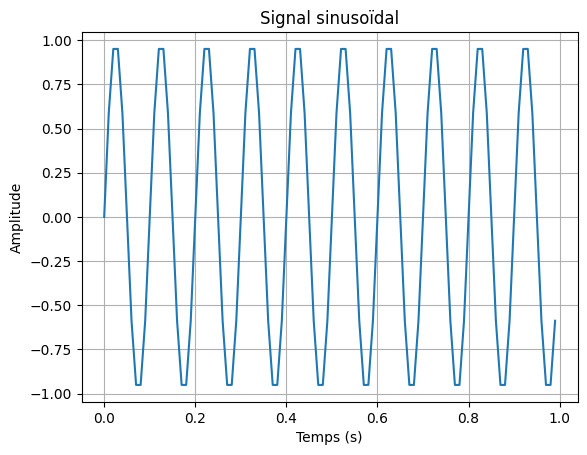

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
f0 = 10
A = 1
phi = 0
fs = 100
T = 1

t = np.linspace(0, T, fs, endpoint=False)
x = A * np.sin(2 * np.pi * f0 * t + phi)

plt.plot(t, x)
plt.title("Signal sinusoïdal")
plt.xlabel("Temps (s)")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

### Ajout de bruit blanc gaussien

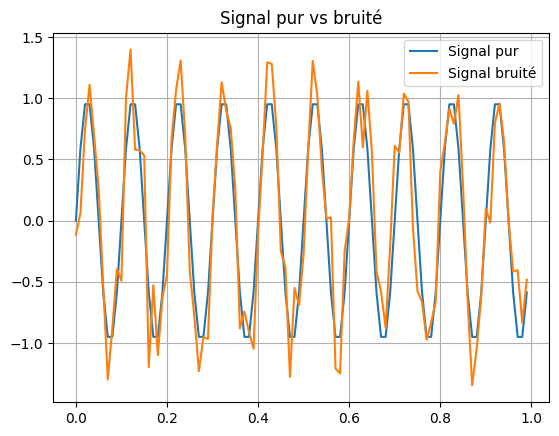

In [2]:
noise = np.random.normal(0, 0.3, len(x))
y = x + noise

plt.plot(t, x, label="Signal pur")
plt.plot(t, y, label="Signal bruité")
plt.legend()
plt.title("Signal pur vs bruité")
plt.grid()
plt.show()

### Signal porte et convolution

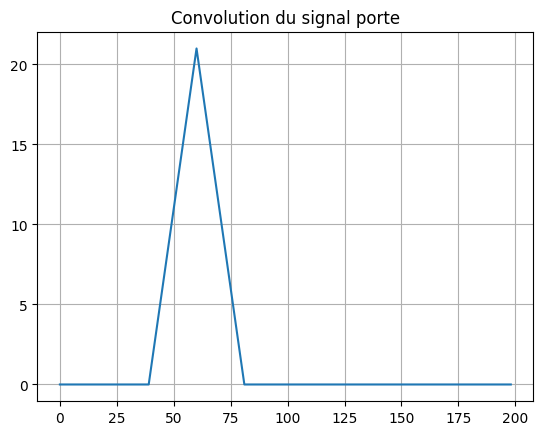

In [3]:
rect = np.zeros(100)
rect[20:41] = 1

conv_result = np.convolve(rect, rect)

plt.plot(conv_result)
plt.title("Convolution du signal porte")
plt.grid()
plt.show()

## TP2 — Analyse spectrale

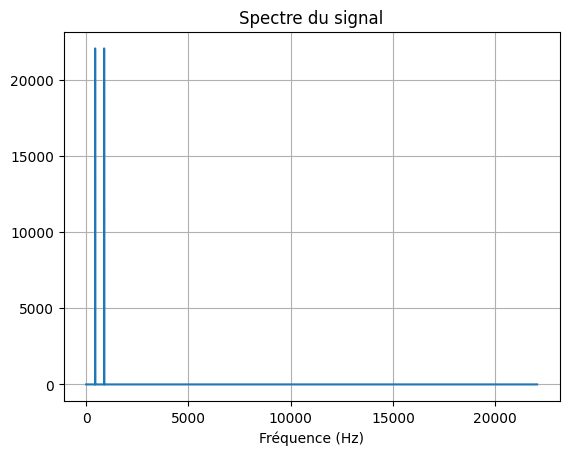

In [7]:
fs = 44100
t = np.linspace(0, 1, fs, endpoint=False)

f1, f2 = 440, 880
signal = np.sin(2*np.pi*f1*t) + np.sin(2*np.pi*f2*t)

fft_vals = np.fft.fft(signal)
freqs = np.fft.fftfreq(len(fft_vals), 1/fs)

plt.plot(freqs[:fs//2], np.abs(fft_vals[:fs//2]))
plt.title("Spectre du signal")
plt.xlabel("Fréquence (Hz)")
plt.grid()
plt.show()

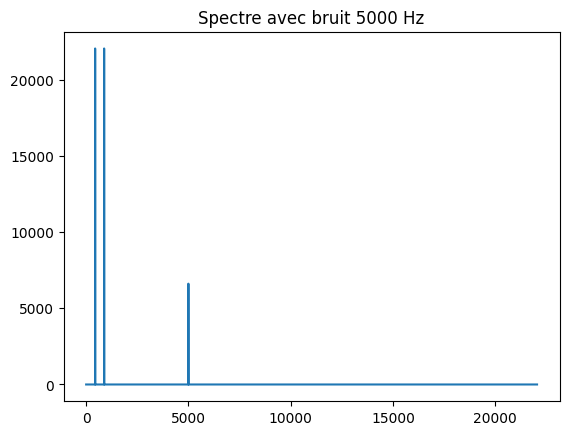

In [8]:
f_noise = 5000
noise = 0.3*np.sin(2*np.pi*f_noise*t)
noisy_signal = signal + noise

fft_noisy = np.fft.fft(noisy_signal)

plt.plot(freqs[:fs//2], np.abs(fft_noisy[:fs//2]))
plt.title("Spectre avec bruit 5000 Hz")
plt.show()

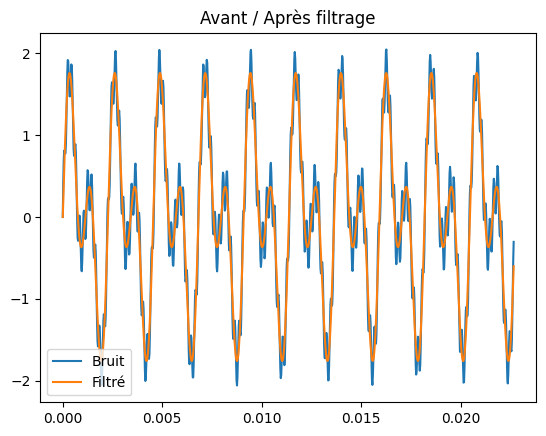

In [9]:
filtered_fft = fft_noisy.copy()
band = (np.abs(freqs) > 4900) & (np.abs(freqs) < 5100)
filtered_fft[band] = 0

filtered_signal = np.fft.ifft(filtered_fft)

plt.plot(t[:1000], noisy_signal[:1000], label="Bruit")
plt.plot(t[:1000], filtered_signal[:1000].real, label="Filtré")
plt.legend()
plt.title("Avant / Après filtrage")
plt.show()

## TP3 — Théorème de Shannon et audio

In [10]:
# Fréquences perceptibles par l'oreille humaine
f_min, f_max = 20, 20000  # Hz

# Théorème de Shannon : fs >= 2*f_max
fs_min = 2 * f_max
print("Fréquence d'échantillonnage minimale selon Shannon:", fs_min, "Hz")

Fréquence d'échantillonnage minimale selon Shannon: 40000 Hz


In [11]:
fs = 44100      # Hz
bits = 16       # bits par échantillon
channels = 2    # stéréo

# Débit binaire en bps
D_bps = fs * bits * channels

# Convertir en Ko/s
D_Kos = D_bps / 8 / 1000

print("Débit binaire:", D_bps, "bps =", round(D_Kos, 2), "Ko/s")

Débit binaire: 1411200 bps = 176.4 Ko/s


In [12]:
duration_sec = 4 * 60  # 4 minutes en secondes

size_bits = D_bps * duration_sec
size_Mo = size_bits / 8 / 1e6
print("Taille approximative d'une chanson de 4 min :", round(size_Mo,2), "Mo")

Taille approximative d'une chanson de 4 min : 42.34 Mo


In [13]:
mp3_bitrate = 128_000  # 128 kbps

factor_compression = D_bps / mp3_bitrate
print("Facteur de compression avec MP3 128 kbps :", round(factor_compression, 2), "fois")

Facteur de compression avec MP3 128 kbps : 11.03 fois


In [14]:
# Image 1024x1024 pixels, 8 bits
width, height, bits_pixel = 1024, 1024, 8

# Nombre de niveaux
niveaux = 2**bits_pixel
print("Nombre de nuances de gris :", niveaux)

# Poids image en Mo
poids_bits = width * height * bits_pixel
poids_Mo = poids_bits / 8 / 1e6
print("Poids image non compressée :", round(poids_Mo,2), "Mo")

# Si 1 bit
bits_pixel1 = 1
poids_Mo1 = width * height * bits_pixel1 / 8 / 1e6
print("Poids image 1 bit :", round(poids_Mo1,3), "Mo")
print("Type d'image : binaire (noir/blanc)")

Nombre de nuances de gris : 256
Poids image non compressée : 1.05 Mo
Poids image 1 bit : 0.131 Mo
Type d'image : binaire (noir/blanc)
